# Topic Modeling: LDA and BERTopic (OpenRouter `text-embedding-3-large`)
This is the **parallel variant** of `topic_modeling.ipynb`.

The only difference is the embedding backend for BERTopic:
- **Original:** `paraphrase-multilingual-mpnet-base-v2` (local SentenceTransformer)
- **This notebook:** `openai/text-embedding-3-large` via [OpenRouter](https://openrouter.ai) API — 3072-dim embeddings, billed per token

Everything else (data loading, LDA, vectorizer, visualisations) is identical.

**Setup:** Set the environment variable `OPENROUTER_API_KEY` before running, or paste your key into the cell below.

In [41]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# Setup Thai font to fix missing glyphs in plots.
font_path = '../../static/font/LINESeedSansTH_Rg.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
print(f"Font loaded: {font_prop.get_name()}")


Font loaded: LINE Seed Sans TH


In [42]:
# Install required libraries
# openai is used to call the OpenRouter-compatible embeddings endpoint.
# AttaCut is included because the upstream preprocessing tokenizes with engine='attacut'.
%pip install pandas numpy scikit-learn pythainlp attacut bertopic openai matplotlib tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [43]:
import os
import pandas as pd
import ast
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

from bertopic import BERTopic
from openai import OpenAI

## 1. Data Loading and Preparation
This notebook uses the newer `sections_v2.csv` structure from `03_data_preparation/output`. The file stores one row per section with raw text, so we normalize the identifier columns and recreate the same Thai tokenization used upstream by `basic_eda.ipynb` via `data/preprocessed_data.csv`: AttaCut tokenization, Thai stopword removal, whitespace stripping, and punctuation/symbol filtering.


In [44]:
# Load the newer section-level dataset and tokenize with the same logic used for basic_eda's preprocessed tokens.
import re
from pythainlp.corpus.common import thai_stopwords
from pythainlp.tokenize import word_tokenize

df = pd.read_csv('../output/sections_v2.csv', encoding='utf-8-sig', engine='python', on_bad_lines='skip')

# Normalize the sections_v2 schema to the column names expected below.
df = df.rename(columns={
    'doc_id': 'constitution_id',
})

df['text'] = df['text'].fillna('').astype(str)
df = df[df['text'].str.strip().ne('')].copy()

stopwords = set(thai_stopwords())

def preprocess_thai(text):
    tokens = word_tokenize(text, engine='attacut')

    clean_tokens = []
    for token in tokens:
        token = token.strip()
        if (
            token
            and token not in stopwords
            and not re.match(r'^[\W_]+$', token)
        ):
            clean_tokens.append(token)

    return clean_tokens

df['tokens'] = df['text'].apply(preprocess_thai)
df['joined_tokens'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))
df['word_count'] = df['tokens'].apply(len)
df = df[df['word_count'] > 0].reset_index(drop=True)

display_columns = ['section_id', 'constitution_id', 'year_th', 'chapter_number', 'section_number', 'text', 'joined_tokens']
display(df[display_columns].head())


,section_id,constitution_id,year_th,chapter_number,section_number,text,joined_tokens
0,const_2475_s_1,const_2475,2475,0,1,สยามประเทศเป็นราชอาณาจักรอันหนึ่งอันเดียว จะแบ...,สยาม ประเทศ ราชอาณาจักร แบ่งแยก ประชาชน สยาม ก...
1,const_2475_s_2,const_2475,2475,0,2,อำนาจอธิปไตยย่อมมาจากปวงชนชาวสยาม พระมหากษัตริ...,อำนาจ อธิปไตย ปวง ชน สยาม พระมหากษัตริย์ ประมุ...
2,const_2475_s_3,const_2475,2475,1,3,องค์พระมหากษัตริย์ดำรงอยู่ในฐานะอันเป็นที่เคาร...,องค์ พระมหากษัตริย์ ดำรง ฐานะ เคารพ สัก ใด ละเมิด
3,const_2475_s_4,const_2475,2475,1,4,พระมหากษัตริย์ต้องทรงเป็นพุทธมามกะ และทรงเป็นอ...,พระมหากษัตริย์ พุทธมามกะ อัครศาสนูปถัมภก
4,const_2475_s_5,const_2475,2475,1,5,พระมหากษัตริย์ทรงดำรงตำแหน่งจอมทัพ สยาม,พระมหากษัตริย์ ดำรง ตำแหน่ง จอมทัพ สยาม


In [45]:
# Define Custom Thai Legal Stopwords
from pythainlp.corpus import thai_stopwords
import pandas as pd

# Start with standard Thai stopwords
base_stopwords = list(thai_stopwords())

# Add legal-specific words that appear frequently but don't define topics
legal_noise = [
    "มาตรา", "ฉบับ", "พ.ศ.", "แห่ง", "ตาม", "นายกรัฐมนตรี", 
    "รัฐมนตรี", "สภา", "สมาชิก", "พระมหากษัตริย์", "อำนาจ",
    "บัญญัติ", "รักษา", "ประกาศ", "ระเบียบ", "ภายใต้", "กรณี"
]

custom_stopwords = list(set(base_stopwords))
print(f"Total stopwords: {len(custom_stopwords)}")


Total stopwords: 1030


## 2. Topic Modeling with LDA
**Latent Dirichlet Allocation (LDA)** is a classic method. It assumes:
* Every document is a mix of topics.
* Every topic is a mix of words.

To use LDA, we first need to count the words using a `CountVectorizer`. It creates a "Document-Term Matrix" (a big table of word counts).

In [46]:
# 2.1 Vectorize the text using List of Tokens (Friend's Style)
from sklearn.feature_extraction.text import CountVectorizer

# Following the EDA style: using the raw list of tokens
# We use tokenizer=lambda x: x because data is already a list of words
vectorizer = CountVectorizer(
    tokenizer=lambda x: x,
    token_pattern=None,
    lowercase=False,
    min_df=5, 
    max_df=0.9, 
    stop_words=custom_stopwords
)
X = vectorizer.fit_transform(df['tokens'])

# 2.2 Train the LDA Model
num_topics_lda = 5
lda_model = LatentDirichletAllocation(n_components=num_topics_lda, random_state=42)

print("Training LDA model...")
lda_model.fit(X)
print("Done!")


Training LDA model...
Done!


### Visualizing LDA Topics
We can look at the top words weight for each topic to understand what it's about.

Plotting top 10 words per topic in LDA:


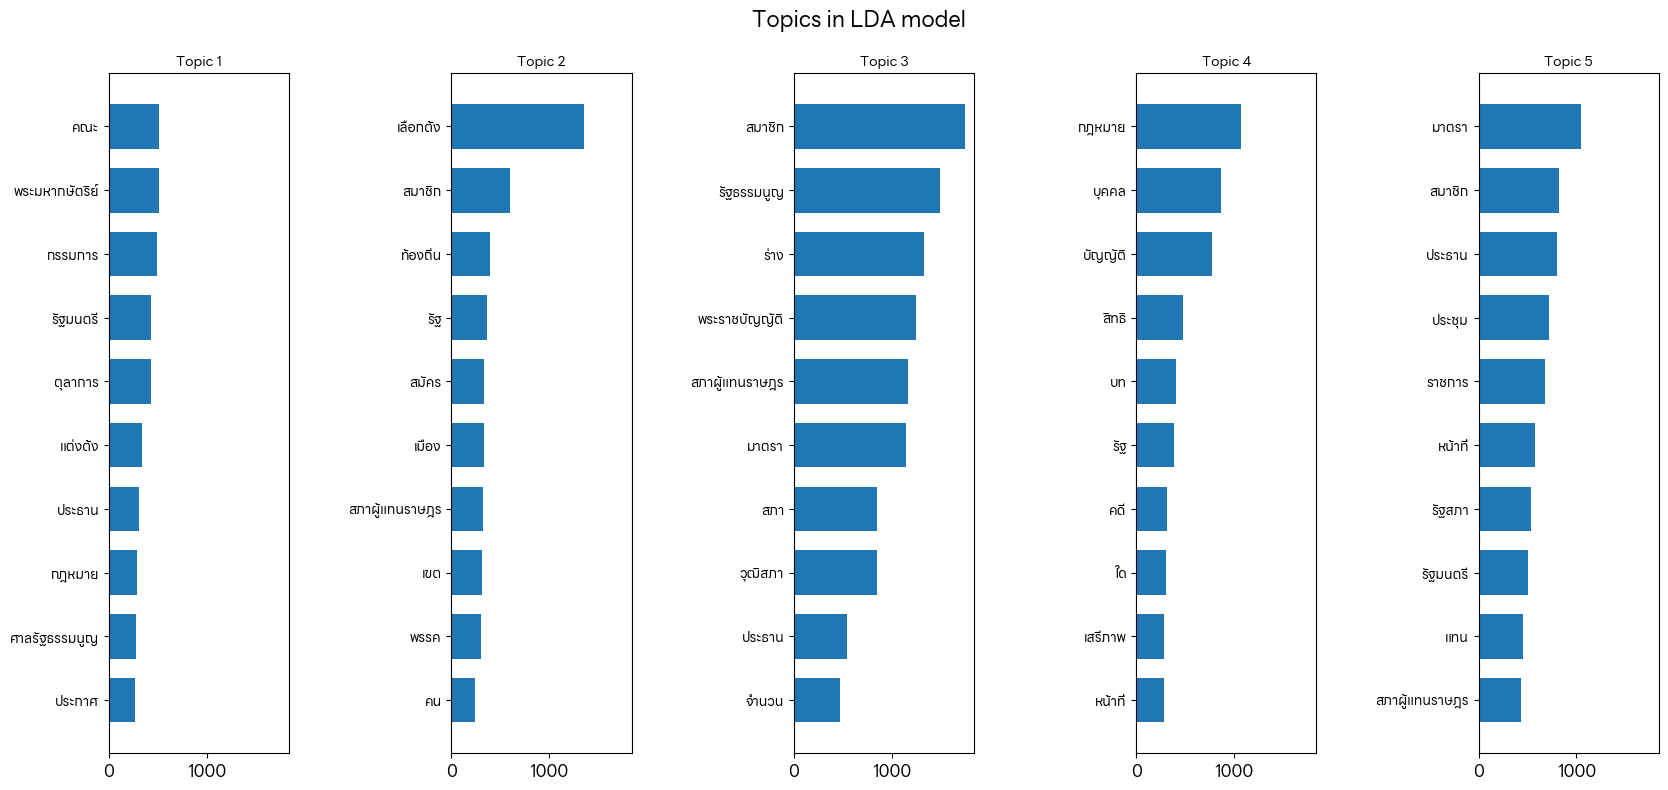

In [47]:
# Function to plot top words using matplotlib
def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(1, 5, figsize=(20, 8), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 14}, fontproperties=font_prop)
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=12)
        
        # Use the custom Thai font for the labels
        for label in ax.get_yticklabels():
            label.set_fontproperties(font_prop)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.suptitle(title, fontsize=16, fontproperties=font_prop)
    plt.show()

print("Plotting top 10 words per topic in LDA:")
plot_top_words(lda_model, vectorizer.get_feature_names_out(), 10, "Topics in LDA model")


## 3. Topic Modeling with BERTopic (OpenRouter embeddings)
**BERTopic** uses embeddings to understand semantic meaning. Here we swap the local model for
**`openai/text-embedding-3-large`** served through OpenRouter — the same OpenAI-compatible API,
just routed through OpenRouter so you can use a single API key for many providers.

Key differences vs the original notebook:
- Embeddings are fetched via HTTP in parallel batches (no local GPU needed).
- The embedding dimension is **3072** instead of 768, which can improve cluster separation.
- Cost: ~$0.13 / million tokens (check OpenRouter pricing for the latest rate).

In [ ]:
# 3.0 OpenRouter API key
# Set OPENROUTER_API_KEY in your shell, or paste the key string here (do NOT commit it).
OPENROUTER_API_KEY = "xxx"
# if not OPENROUTER_API_KEY:
#     raise ValueError("OPENROUTER_API_KEY is not set. Export it in your shell or paste it above.")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
BATCH_SIZE = 64  # OpenRouter accepts up to 2048 inputs per request; 64 keeps payloads small

In [49]:
# 3.1 Parallel batch embedding via OpenRouter
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

def embed_batch(batch: list[str]) -> list[list[float]]:
    response = client.embeddings.create(model=EMBED_MODEL, input=batch)
    # Items are returned in the same order as the input.
    return [item.embedding for item in sorted(response.data, key=lambda x: x.index)]

def embed_texts_parallel(texts: list[str], batch_size: int = BATCH_SIZE, max_workers: int = 8) -> np.ndarray:
    batches = [texts[i : i + batch_size] for i in range(0, len(texts), batch_size)]
    results: dict[int, list[list[float]]] = {}

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(embed_batch, batch): idx for idx, batch in enumerate(batches)}
        for future in tqdm(as_completed(futures), total=len(futures), desc="Embedding batches"):
            idx = futures[future]
            results[idx] = future.result()

    ordered = []
    for i in range(len(batches)):
        ordered.extend(results[i])
    return np.array(ordered, dtype="float32")

# 1. Use raw text for semantic meaning
docs_for_embeddings = df['text'].tolist()

# 2. Join tokens for BERTopic's c-TF-IDF step
docs_for_ctfidf = df['tokens'].apply(lambda x: ' '.join(x)).tolist()

print(f"Generating embeddings for {len(docs_for_embeddings)} documents via OpenRouter ({EMBED_MODEL})...")
embeddings = embed_texts_parallel(docs_for_embeddings)
print(f"Embeddings shape: {embeddings.shape}")  # expected (n_docs, 3072)

Generating embeddings for 2797 documents via OpenRouter (sentence-transformers/all-mpnet-base-v2)...


Embedding batches: 100%|██████████| 44/44 [00:21<00:00,  2.02it/s]

Embeddings shape: (2797, 768)


In [87]:
# 3.2 Train BERTopic using the OpenRouter embeddings
# We pass precomputed embeddings, so BERTopic skips any internal embedding model.
#
# language="multilingual" is required: BERTopic._preprocess_text strips all non-ASCII chars
# when language="english" (the default), which removes every Thai character before
# the vectorizer runs and causes an empty vocabulary error.
vectorizer_model = CountVectorizer(
    token_pattern=r"[฀-๿]+",
    lowercase=False,
    min_df=2,
)

topic_model = BERTopic(
    language="multilingual",
    vectorizer_model=vectorizer_model,
    verbose=True
)

print("Training BERTopic...")
topics, probs = topic_model.fit_transform(docs_for_ctfidf, embeddings=embeddings)
print("Done!")

2026-05-03 22:14:36,685 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Training BERTopic...


2026-05-03 22:14:44,693 - BERTopic - Dimensionality - Completed ✓
2026-05-03 22:14:44,695 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 22:14:44,746 - BERTopic - Cluster - Completed ✓
2026-05-03 22:14:44,748 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 22:14:44,800 - BERTopic - Representation - Completed ✓


Done!


In [88]:
# Let's look at the topics found by BERTopic
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))


,Topic,Count,Name,Representation,Representative_Docs
0,-1,151,-1_มาตรา_รัฐธรรมนูญ_เลือกตั้ง_หน้าที่,"[มาตรา, รัฐธรรมนูญ, เลือกตั้ง, หน้าที่, รัฐมนต...",[ดำเนิน เลือกตั้ง สมาชิก สภาผู้แทนราษฎร รัฐธรร...
1,0,309,0_กฎหมาย_ท้องถิ่น_บุคคล_บัญญัติ,"[กฎหมาย, ท้องถิ่น, บุคคล, บัญญัติ, สิทธิ, รัฐ,...",[ศาลปกครอง อํานาจ พิจารณา พิพากษา คดี พิพาท หน...
2,1,153,1_ประชุม_คดี_สภาผู้แทน_ประธาน,"[ประชุม, คดี, สภาผู้แทน, ประธาน, สิทธิ, วุฒิสภ...",[ประธาน รอง ประธาน วุฒิสภา ประธาน รอง ประธาน ส...
3,2,148,2_มาตรา_พระราชบัญญัติ_ร่าง_สภาผู้แทนราษฎร,"[มาตรา, พระราชบัญญัติ, ร่าง, สภาผู้แทนราษฎร, ค...",[บังคับ มาตรา 146 สภาผู้แทนราษฎร พิจารณาร่าง พ...
4,3,148,3_บังคับ_ประชุม_มาตรา_วรรค,"[บังคับ, ประชุม, มาตรา, วรรค, สภาผู้แทนราษฎร, ...",[บท บัญญัติ มาตรา 154 บังคับ ร่าง ข้อ บังคับ ป...
5,4,123,4_พระมหากษัตริย์_องคมนตรี_งบ_หน้าที่,"[พระมหากษัตริย์, องคมนตรี, งบ, หน้าที่, ปี, สิ...",[พระมหากษัตริย์ เลือก แต่งตั้ง คุณวุฒิ ประธาน ...
6,5,113,5_พระมหากษัตริย์_แต่งตั้ง_กฎหมาย_รัฐสภา,"[พระมหากษัตริย์, แต่งตั้ง, กฎหมาย, รัฐสภา, ประ...",[ประธาน วุฒิสภา ประธาน รัฐสภา ประธาน สภาผู้แทน...
7,6,94,6_สภา_รัฐสภา_แต่งตั้ง_ประชุม,"[สภา, รัฐสภา, แต่งตั้ง, ประชุม, สมาชิก, พระมหา...",[พระมหากษัตริย์ นายก รัฐมนตรี คน รัฐมนตรี สี่ ...
8,7,93,7_รัฐธรรมนูญ_ชื่อ_มาตรา_สมาชิก,"[รัฐธรรมนูญ, ชื่อ, มาตรา, สมาชิก, คะแนน, สอง, ...",[รัฐธรรมนูญ หลัก เกณฑ์ วิธีการ 1 ญัตติ คณะ รัฐ...
9,8,91,8_พระมหากษัตริย์_พระราชอำนาจ_พิพากษา_อรรถคดี,"[พระมหากษัตริย์, พระราชอำนาจ, พิพากษา, อรรถคดี...",[พิพากษา ตุลาการ อิสระ พิจารณา พิพากษา อรรถคดี...


In [89]:
# Visualize the top words per topic as a bar chart (BERTopic natively supports Plotly)
fig = topic_model.visualize_barchart(top_n_topics=8)
fig


In [90]:
# Visualize the distance between topics
fig2 = topic_model.visualize_topics()
fig2.show()


In [91]:
# 4. Advanced BERTopic Visualizations
# Visualize the hierarchical structure of topics
hierarchical_topics = topic_model.hierarchical_topics(docs_for_ctfidf)
fig_hierarchy = topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)
fig_hierarchy.show(figsize=(10, 20))

# Visualize Topic Heatmap (Similarity Matrix)
fig_heatmap = topic_model.visualize_heatmap()
fig_heatmap.show(figsize=(10, 20))


100%|██████████| 45/45 [00:00<00:00, 724.15it/s]


In [92]:
topic_model.generate_topic_labels()
topic_info = topic_model.get_topic_info()
# display(topic_info.head(20))
print(topic_info.head(20))

# topic_info.to_csv("topic_info.csv", index=False, encoding='utf-8-sig')
# topic.info
# display(topic_info.to_dict(orient='records'))
# See the full "Representative_Docs" for Topic 0

    Topic  Count                                          Name  \
0      -1    151         -1_มาตรา_รัฐธรรมนูญ_เลือกตั้ง_หน้าที่   
1       0    309               0_กฎหมาย_ท้องถิ่น_บุคคล_บัญญัติ   
2       1    153                 1_ประชุม_คดี_สภาผู้แทน_ประธาน   
3       2    148     2_มาตรา_พระราชบัญญัติ_ร่าง_สภาผู้แทนราษฎร   
4       3    148                    3_บังคับ_ประชุม_มาตรา_วรรค   
5       4    123          4_พระมหากษัตริย์_องคมนตรี_งบ_หน้าที่   
6       5    113       5_พระมหากษัตริย์_แต่งตั้ง_กฎหมาย_รัฐสภา   
7       6     94                  6_สภา_รัฐสภา_แต่งตั้ง_ประชุม   
8       7     93                7_รัฐธรรมนูญ_ชื่อ_มาตรา_สมาชิก   
9       8     91  8_พระมหากษัตริย์_พระราชอำนาจ_พิพากษา_อรรถคดี   
10      9     84       9_ประธาน_แต่งตั้ง_ประชุม_พระมหากษัตริย์   
11     10     82                    10_หน่วย_รัฐ_งาน_เลือกตั้ง   
12     11     79         11_พระมหากษัตริย์_กฎหมาย_ส่งเสริม_รัฐ   
13     12     67                      12_สภา_สอง_สมาชิก_ประชุม   
14     13 

In [93]:
reduced_model = topic_model.reduce_topics(docs_for_ctfidf, nr_topics="auto")
reduced_info = reduced_model.get_topic_info()
display(reduced_info)
print("topics (excl. -1):", (reduced_info["Topic"] != -1).sum())

reduced_info.to_csv("reduced_topic_info.csv", index=False, encoding='utf-8-sig')

2026-05-03 22:15:22,937 - BERTopic - Topic reduction - Reducing number of topics
2026-05-03 22:15:22,950 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 22:15:22,999 - BERTopic - Representation - Completed ✓
2026-05-03 22:15:23,000 - BERTopic - Topic reduction - Reduced number of topics from 47 to 15


,Topic,Count,Name,Representation,Representative_Docs
0,-1,151,-1_มาตรา_รัฐธรรมนูญ_เลือกตั้ง_หน้าที่,"[มาตรา, รัฐธรรมนูญ, เลือกตั้ง, หน้าที่, สมาชิก...",[หมวด 4 รัฐธรรมนูญ ราชอาณาจักรไทย ฉบับ พุทธศัก...
1,0,934,0_สมาชิก_ประชุม_ประธาน_สภา,"[สมาชิก, ประชุม, ประธาน, สภา, รัฐสภา, ใด, กฎหม...",[ประชุม วุฒิสภา ประชุม สภาผู้แทนราษฎร ประชุม ร...
2,1,370,1_มาตรา_ร่าง_พระราชบัญญัติ_สมาชิก,"[มาตรา, ร่าง, พระราชบัญญัติ, สมาชิก, สภาผู้แทน...",[บังคับ มาตรา 152 วุฒิสภา พิจารณาร่าง พระราชบั...
3,2,309,2_กฎหมาย_บัญญัติ_บุคคล_ท้องถิ่น,"[กฎหมาย, บัญญัติ, บุคคล, ท้องถิ่น, สิทธิ, รัฐ,...",[บุคคล เสรีภาพ คิดเห็น จำกัด เสรีภาพ วรรค เว้น...
4,3,246,3_พระมหากษัตริย์_กฎหมาย_พระราชอำนาจ_รัฐ,"[พระมหากษัตริย์, กฎหมาย, พระราชอำนาจ, รัฐ, พิพ...",[พระมหากษัตริย์ พระราชอำนาจ ตรา พระราชกฤษฎีกา ...
5,4,180,4_มาตรา_รัฐธรรมนูญ_ประชุม_วรรค,"[มาตรา, รัฐธรรมนูญ, ประชุม, วรรค, ร่าง, บังคับ...",[ห้า ปี รัฐสภา ชุด รัฐธรรมนูญ ชอบ บุคคล สมควร ...
6,5,171,5_พระมหากษัตริย์_บุคคล_กฎหมาย_หน้าที่,"[พระมหากษัตริย์, บุคคล, กฎหมาย, หน้าที่, พระรา...","[บุคคล หน้าที่ กฎหมาย, บุคคล หน้าที่ กฎหมาย, บ..."
7,6,153,6_กฎหมาย_บัญญัติ_พระมหากษัตริย์_รัฐ,"[กฎหมาย, บัญญัติ, พระมหากษัตริย์, รัฐ, บท, อำน...",[อำนาจ อธิปไตย ปวง ชน ไทย พระมหากษัตริย์ ประมุ...
8,7,107,7_หน่วย_เลือกตั้ง_รัฐ_สมาชิก,"[หน่วย, เลือกตั้ง, รัฐ, สมาชิก, งาน, ราชการ, ส...",[สมาชิก สภาผู้แทนราษฎร 1 ดำรง ตำแหน่ง หน้าที่ ...
9,8,53,8_พุทธศักราช_รัฐธรรมนูญ_สืบ_ราชอาณาจักรไทย,"[พุทธศักราช, รัฐธรรมนูญ, สืบ, ราชอาณาจักรไทย, ...",[บังคับ มาตรา 21 สืบราชสมบัติ นัย กฎ มณเฑียรบา...


topics (excl. -1): 14
